In [1]:
!pip install gseapy
!pip install adjustText
!pip install pycombat
!pip install bioinfokit
!pip install rpy2
!apt-get install -y r-base-dev

!R -e "if (!requireNamespace('BiocManager', quietly=TRUE)) install.packages('BiocManager')"

!R -e "BiocManager::install('limma', ask=FALSE, update=FALSE)"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.1/88.1 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for bioinfokit: filename=bioinfokit-2.1.4-py3-none-any.whl size=59220 sha256=2ea0b38410dcbb28163c4521b9d135f3261d77683f1f25e81f8ec17a3aad07c5
  Stored in directory: /root/.cache/pip/wheels/b4/76/43/7fa2c349dac62f041fe8d85c9f48e47ca25fc39fd79d0b5f5e
Successfully built bioinfokit
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base-dev is already the newest version (4.6.0-4.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.

R version 4.6.0 (2026-04-24) -- "Because it was There"
Copyright (C) 2026 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()'

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_ind

In [3]:

import gseapy as gp
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns
import requests
from adjustText import adjust_text
import seaborn as sns
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

pandas2ri.activate()


In [4]:
normal = pd.read_csv('/content/proteome_normal_filtered (1).csv',sep=',')
tumor = pd.read_csv('/content/proteome_tumor_filtered (1).csv',sep=',')


In [5]:
print(normal.head())
print(tumor.head())

print(normal.shape)
print(tumor.shape)

  GeneSymbol  C3L.00001  C3L.00009  C3L.00080  C3L.00083  C3L.00093  \
0       A1BG     2.9287     1.0722     3.0939     2.7488     2.9565   
1        A2M     5.0086     1.7726     5.4187     3.5303     4.1603   
2       AAAS    -0.6113    -0.1973    -0.0310     0.2155     0.3270   
3       AACS    -2.9004    -2.3184    -0.9958    -0.1148    -2.5916   
4      AADAC    -1.0494     0.3678    -3.0383    -0.1060     0.7810   

   C3L.00094  C3L.00095  C3L.00140  C3L.00144  ...  C3N.02423  C3N.02424  \
0     2.0367     2.4594     1.8415    -0.1123  ...     2.7894     1.3342   
1     1.8520     1.8005     3.6394     0.3259  ...     3.4155     3.0909   
2     0.2232     0.9110    -0.0244    -0.3843  ...    -0.3339     0.5017   
3    -2.6346    -0.9460    -1.2254    -1.6423  ...    -2.0240    -1.5976   
4     4.0727    -1.1197    -2.5479    -0.3805  ...     1.4286     3.6327   

   C3N.02433  C3N.02529  C3N.02572  C3N.02582  C3N.02586  C3N.02587  \
0     3.4093     1.9110     1.5818     1.8277

In [6]:
normal.rename(columns={normal.columns[0]: 'GeneSymbol'}, inplace=True)
tumor.rename(columns={tumor.columns[0]: 'GeneSymbol'}, inplace=True)

In [7]:
normal['GeneSymbol'] = normal['GeneSymbol'].astype(str).str.upper().str.strip()
tumor['GeneSymbol'] = tumor['GeneSymbol'].astype(str).str.upper().str.strip()

In [8]:
normal = normal.groupby('GeneSymbol').mean().reset_index()
tumor = tumor.groupby('GeneSymbol').mean().reset_index()

In [9]:
normal.duplicated().sum()

np.int64(0)

In [10]:
tumor.duplicated().sum()

np.int64(0)

In [11]:
normal[normal.duplicated()]

,GeneSymbol,C3L.00001,C3L.00009,C3L.00080,C3L.00083,C3L.00093,C3L.00094,C3L.00095,C3L.00140,C3L.00144,...,C3N.02423,C3N.02424,C3N.02433,C3N.02529,C3N.02572,C3N.02582,C3N.02586,C3N.02587,C3N.02588,C3N.02729


In [12]:
 normal.isnull().sum().sum()

np.int64(77253)

In [13]:
normal = normal.set_index('GeneSymbol')

tumor = tumor.set_index('GeneSymbol')

expr = pd.concat([normal, tumor], axis=1)

print(expr.shape)

expr.head()

(10316, 192)


,C3L.00001,C3L.00009,C3L.00080,C3L.00083,C3L.00093,C3L.00094,C3L.00095,C3L.00140,C3L.00144,C3L.00263,...,C3N.02423,C3N.02424,C3N.02433,C3N.02529,C3N.02572,C3N.02582,C3N.02586,C3N.02587,C3N.02588,C3N.02729
GeneSymbol,,,,,,,,,,,,,,,,,,,,,
A1BG,2.9287,1.0722,3.0939,2.7488,2.9565,2.0367,2.4594,1.8415,-0.1123,3.3675,...,-1.8646,-2.0689,-1.8656,-2.2154,-1.4006,-3.3718,-1.2578,-1.1300,-1.6323,-0.7255
A2M,5.0086,1.7726,5.4187,3.5303,4.1603,1.8520,1.8005,3.6394,0.3259,3.5962,...,-2.7064,-3.3498,-2.5679,-3.9010,-3.4726,-4.1354,-3.0975,-1.7842,-2.8213,-3.2235
AAAS,-0.6113,-0.1973,-0.0310,0.2155,0.3270,0.2232,0.9110,-0.0244,-0.3843,-0.0812,...,-0.3437,0.6080,0.0946,-0.2636,0.2486,-0.0534,-0.7937,-0.2201,-0.9973,0.2707
AACS,-2.9004,-2.3184,-0.9958,-0.1148,-2.5916,-2.6346,-0.9460,-1.2254,-1.6423,-0.7223,...,-1.4159,0.0956,-0.5035,2.8282,-0.8797,2.4697,-0.2161,1.4290,0.5833,2.2248
AADAC,-1.0494,0.3678,-3.0383,-0.1060,0.7810,4.0727,-1.1197,-2.5479,-0.3805,0.0331,...,-0.4668,-4.6997,9.3517,-5.0812,-5.6845,-4.8449,-3.9256,-2.3886,-3.4507,6.2018


In [14]:
expr = expr.apply(pd.to_numeric, errors='coerce')

In [15]:
missing_fraction = expr.isnull().mean(axis=1)

expr = expr[missing_fraction <= 0.30]

print(expr.shape)

(9194, 192)


In [16]:
imputer = KNNImputer(n_neighbors=5)

expr_imputed = pd.DataFrame(
    imputer.fit_transform(expr),
    index=expr.index,
    columns=expr.columns
)

In [17]:
expr_imputed.min().min()

-27.4378

In [18]:
expr_log = expr_imputed.copy()

In [19]:
n_normal = normal.shape[1]

n_tumor = tumor.shape[1]

In [20]:
normal_data = expr_log.iloc[:, :n_normal]
tumor_data = expr_log.iloc[:, n_normal:]

In [21]:
print(expr.columns)

Index(['C3L.00001', 'C3L.00009', 'C3L.00080', 'C3L.00083', 'C3L.00093',
       'C3L.00094', 'C3L.00095', 'C3L.00140', 'C3L.00144', 'C3L.00263',
       ...
       'C3N.02423', 'C3N.02424', 'C3N.02433', 'C3N.02529', 'C3N.02572',
       'C3N.02582', 'C3N.02586', 'C3N.02587', 'C3N.02588', 'C3N.02729'],
      dtype='object', length=192)


In [22]:
expr_log = expr_log[~expr_log.index.duplicated(keep='first')]

expr_r = expr_log.copy()

limma

In [23]:
# expression matrix
expr_r = expr_log.copy()

# sample groups
group_labels = ['Normal'] * normal_data.shape[1] + \
               ['Tumor'] * tumor_data.shape[1]

# transpose for limma
expr_r = expr_r.T

# send to R
ro.globalenv['expr_matrix'] = pandas2ri.py2rpy(expr_r)

ro.globalenv['groups'] = ro.StrVector(group_labels)

# R limma code
ro.r('''
library(limma)

design <- model.matrix(~0 + factor(groups))
colnames(design) <- c("Normal", "Tumor")

fit <- lmFit(t(expr_matrix), design)

contrast.matrix <- makeContrasts(
    Tumor-Normal,
    levels=design
)

fit2 <- contrasts.fit(fit, contrast.matrix)

fit2 <- eBayes(fit2)

results <- topTable(
    fit2,
    number=Inf,
    adjust.method="BH"
)
''')

# get results back
results = pandas2ri.rpy2py(
    ro.r['results']
)

results = results.reset_index()

results = results.rename(columns={
    'index': 'GeneSymbol',
    'adj.P.Val': 'adj.P.Val',
    'P.Value': 'P.Value',
    'logFC': 'logFC'
})

results.head()

/usr/local/lib/python3.12/dist-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


,GeneSymbol,logFC,AveExpr,t,P.Value,adj.P.Val,B
0,PALM2-AKAP2,-4.825396,0.077122,-37.413862,1.619873e-90,1.489312e-86,196.154585
1,CAVIN2,-7.151122,-0.412946,-37.197359,4.343977e-90,1.996926e-86,195.174849
2,EHD2,-6.612648,-0.301709,-36.286389,2.892871e-88,8.865685e-85,191.003625
3,HSPA12B,-5.915731,-0.108830,-35.566092,8.461414e-87,1.944856e-83,187.648515
4,SHANK3,-4.426834,0.137516,-35.481179,1.263917e-86,2.324090e-83,187.249622


In [68]:
results = pandas2ri.rpy2py(
    ro.r['results']
)

results = results.reset_index()

results = results.rename(columns={
    'index': 'GeneSymbol'
})

results.head()

,GeneSymbol,logFC,AveExpr,t,P.Value,adj.P.Val,B
0,PALM2-AKAP2,-4.825396,0.077122,-37.413862,1.619873e-90,1.489312e-86,196.154585
1,CAVIN2,-7.151122,-0.412946,-37.197359,4.343977e-90,1.996926e-86,195.174849
2,EHD2,-6.612648,-0.301709,-36.286389,2.892871e-88,8.865685e-85,191.003625
3,HSPA12B,-5.915731,-0.108830,-35.566092,8.461414e-87,1.944856e-83,187.648515
4,SHANK3,-4.426834,0.137516,-35.481179,1.263917e-86,2.324090e-83,187.249622


In [69]:
results = results.replace([np.inf, -np.inf], np.nan)

results = results.dropna(subset=['P.Value'])

In [70]:
results.isna().sum()

,0
GeneSymbol,0
logFC,0
AveExpr,0
t,0
P.Value,0
adj.P.Val,0
B,0


In [71]:
results = results.sort_values(
    by='adj.P.Val'
)

results.head()

,GeneSymbol,logFC,AveExpr,t,P.Value,adj.P.Val,B
0,PALM2-AKAP2,-4.825396,0.077122,-37.413862,1.619873e-90,1.489312e-86,196.154585
1,CAVIN2,-7.151122,-0.412946,-37.197359,4.343977e-90,1.996926e-86,195.174849
2,EHD2,-6.612648,-0.301709,-36.286389,2.892871e-88,8.865685e-85,191.003625
3,HSPA12B,-5.915731,-0.108830,-35.566092,8.461414e-87,1.944856e-83,187.648515
4,SHANK3,-4.426834,0.137516,-35.481179,1.263917e-86,2.324090e-83,187.249622


In [72]:
biomarkers = results[
    (results['adj.P.Val'] < 0.05) &
    (abs(results['logFC']) > 1)
]
biomarkers


,GeneSymbol,logFC,AveExpr,t,P.Value,adj.P.Val,B
0,PALM2-AKAP2,-4.825396,0.077122,-37.413862,1.619873e-90,1.489312e-86,196.154585
1,CAVIN2,-7.151122,-0.412946,-37.197359,4.343977e-90,1.996926e-86,195.174849
2,EHD2,-6.612648,-0.301709,-36.286389,2.892871e-88,8.865685e-85,191.003625
3,HSPA12B,-5.915731,-0.108830,-35.566092,8.461414e-87,1.944856e-83,187.648515
4,SHANK3,-4.426834,0.137516,-35.481179,1.263917e-86,2.324090e-83,187.249622
...,...,...,...,...,...,...,...
7425,IGF2BP1,1.020104,-1.564251,2.287182,2.326737e-02,2.880692e-02,-5.297009
7431,USP29,1.151818,-1.935018,2.275605,2.396554e-02,2.964736e-02,-5.322826
7460,FABP7,1.327384,-4.014414,2.223107,2.736612e-02,3.372258e-02,-5.438333
7520,ERAP2,-1.008910,-0.537131,-2.152114,3.262727e-02,3.988501e-02,-5.590456


In [73]:
print(biomarkers)

       GeneSymbol     logFC   AveExpr          t       P.Value     adj.P.Val  \
0     PALM2-AKAP2 -4.825396  0.077122 -37.413862  1.619873e-90  1.489312e-86   
1          CAVIN2 -7.151122 -0.412946 -37.197359  4.343977e-90  1.996926e-86   
2            EHD2 -6.612648 -0.301709 -36.286389  2.892871e-88  8.865685e-85   
3         HSPA12B -5.915731 -0.108830 -35.566092  8.461414e-87  1.944856e-83   
4          SHANK3 -4.426834  0.137516 -35.481179  1.263917e-86  2.324090e-83   
...           ...       ...       ...        ...           ...           ...   
7425      IGF2BP1  1.020104 -1.564251   2.287182  2.326737e-02  2.880692e-02   
7431        USP29  1.151818 -1.935018   2.275605  2.396554e-02  2.964736e-02   
7460        FABP7  1.327384 -4.014414   2.223107  2.736612e-02  3.372258e-02   
7520        ERAP2 -1.008910 -0.537131  -2.152114  3.262727e-02  3.988501e-02   
7578        S100P  1.237254 -3.036067   2.077690  3.905806e-02  4.738089e-02   

               B  
0     196.154585  
1

In [74]:
biomarkers = biomarkers.sort_values(
    by=['adj.P.Val', 'logFC'],
    ascending=[True, False]
)


In [75]:
top_biomarkers = biomarkers[
    abs(biomarkers['logFC']) > 2
].head(20)

top_biomarkers

,GeneSymbol,logFC,AveExpr,t,P.Value,adj.P.Val,B
0,PALM2-AKAP2,-4.825396,0.077122,-37.413862,1.619873e-90,1.489312e-86,196.154585
1,CAVIN2,-7.151122,-0.412946,-37.197359,4.343977e-90,1.996926e-86,195.174849
2,EHD2,-6.612648,-0.301709,-36.286389,2.892871e-88,8.865685e-85,191.003625
3,HSPA12B,-5.915731,-0.108830,-35.566092,8.461414e-87,1.944856e-83,187.648515
4,SHANK3,-4.426834,0.137516,-35.481179,1.263917e-86,2.324090e-83,187.249622
5,CAVIN1,-6.460174,-0.180602,-34.522373,1.233299e-84,1.889825e-81,182.695193
7,RASIP1,-4.944184,0.075126,-33.775133,4.670321e-83,5.367366e-80,179.080511
6,CLIC5,-7.271668,-0.454412,-33.791350,4.313494e-83,5.367366e-80,179.159578
8,STARD13,-2.985876,0.303781,-33.085682,1.405299e-81,1.435591e-78,175.693487
9,KANK3,-5.810316,0.020284,-32.813330,5.467141e-81,5.026490e-78,174.341563


validation

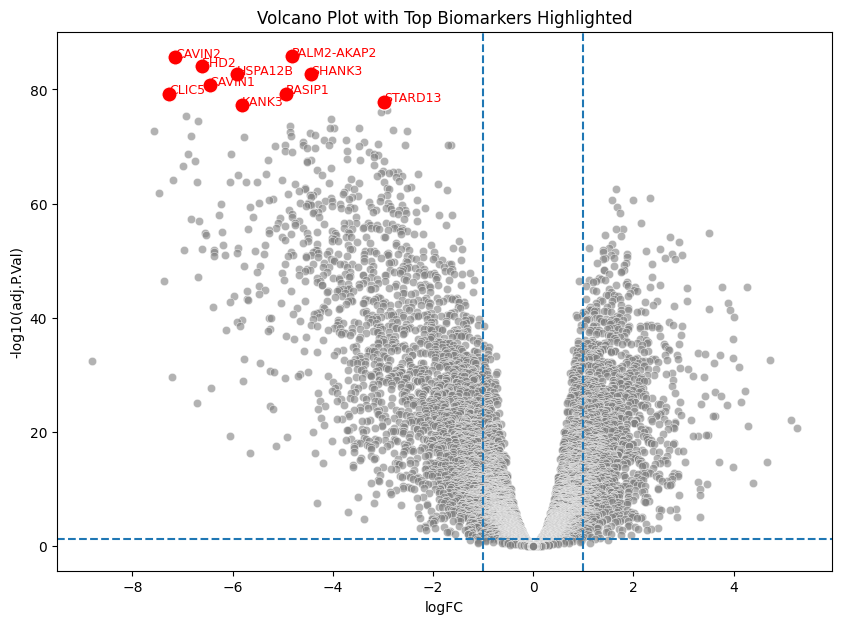

In [76]:
results['minus_log10_pvalue'] = -np.log10(results['adj.P.Val'])

# top genes (choose 10 most significant)
top_genes = results.nsmallest(10, 'adj.P.Val')

plt.figure(figsize=(10,7))

# base plot
sns.scatterplot(
    data=results,
    x='logFC',
    y='minus_log10_pvalue',
    color='grey',
    alpha=0.6
)

# highlight top genes
sns.scatterplot(
    data=top_genes,
    x='logFC',
    y='minus_log10_pvalue',
    color='red',
    s=120
)

# add gene labels
for _, row in top_genes.iterrows():
    plt.text(
        row['logFC'],
        row['minus_log10_pvalue'],
        row['GeneSymbol'],   # change if your column name differs
        fontsize=9,
        color='red'
    )

# threshold lines
plt.axvline(1, linestyle='--')
plt.axvline(-1, linestyle='--')
plt.axhline(-np.log10(0.05), linestyle='--')

plt.title("Volcano Plot with Top Biomarkers Highlighted")
plt.xlabel("logFC")
plt.ylabel("-log10(adj.P.Val)")

plt.show()

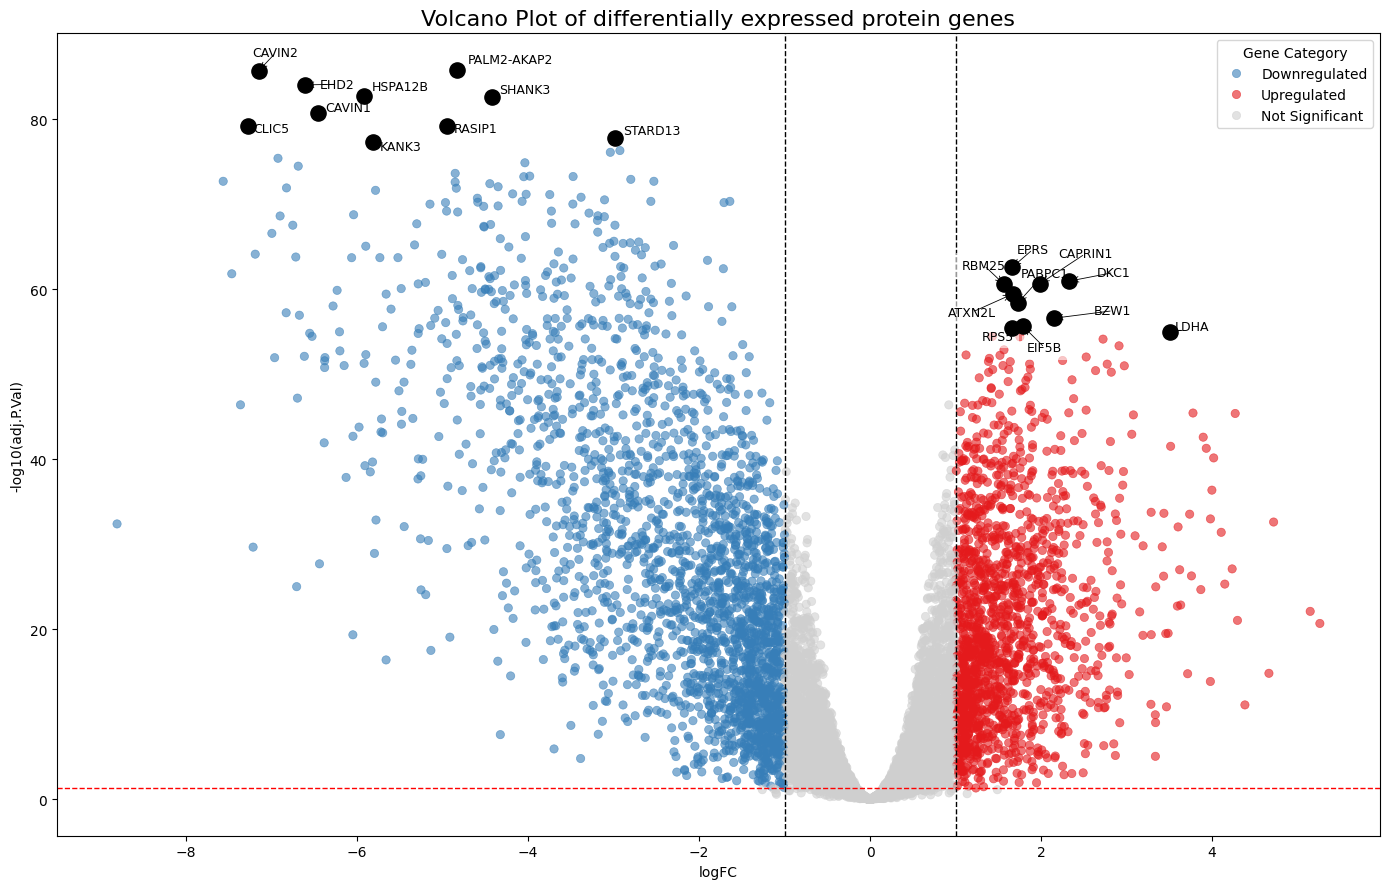

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# -------------------------
# compute significance
# -------------------------


results['group'] = 'Not Significant'

results.loc[
    (results['logFC'] > 1) & (results['adj.P.Val'] < 0.05),
    'group'
] = 'Upregulated'

results.loc[
    (results['logFC'] < -1) & (results['adj.P.Val'] < 0.05),
    'group'
] = 'Downregulated'

# -------------------------
# TOP 20 genes (balanced: up + down)
# -------------------------
top_up = results[(results['logFC'] > 1)].nsmallest(10, 'adj.P.Val')
top_down = results[(results['logFC'] < -1)].nsmallest(10, 'adj.P.Val')

top_genes = pd.concat([top_up, top_down]).copy()

# -------------------------
# plot
# -------------------------
plt.figure(figsize=(14,9))

sns.scatterplot(
    data=results,
    x='logFC',
    y='minus_log10_pvalue',
    hue='group',
    palette={
        'Not Significant': '#cfcfcf',
        'Upregulated': '#e41a1c',
        'Downregulated': '#377eb8'
    },
    alpha=0.6,
    edgecolor=None
)

# highlight top genes
plt.scatter(
    top_genes['logFC'],
    top_genes['minus_log10_pvalue'],
    c='black',
    s=120,

    zorder=5
)

# -------------------------
# labels (NO jitter for stability)
# -------------------------
texts = []
for _, row in top_genes.iterrows():
    texts.append(
        plt.text(
            row['logFC'],
            row['minus_log10_pvalue'],
            row['GeneSymbol'],
            fontsize=9,
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
        )
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='black', lw=0.6),
    expand_text=(1.5, 1.5),
    expand_points=(1.5, 1.5),
    force_text=(0.6, 0.6),
    force_points=(0.6, 0.6)
)

# -------------------------
# threshold lines
# -------------------------
plt.axvline(1, linestyle='--', color='black', linewidth=1)
plt.axvline(-1, linestyle='--', color='black', linewidth=1)
plt.axhline(-np.log10(0.05), linestyle='--', color='red', linewidth=1)

plt.title("Volcano Plot of differentially expressed protein genes", fontsize=16)
plt.xlabel("logFC")
plt.ylabel("-log10(adj.P.Val)")

plt.legend(title="Gene Category")
plt.tight_layout()
plt.show()

In [103]:
results.to_csv("results.csv", index=False)

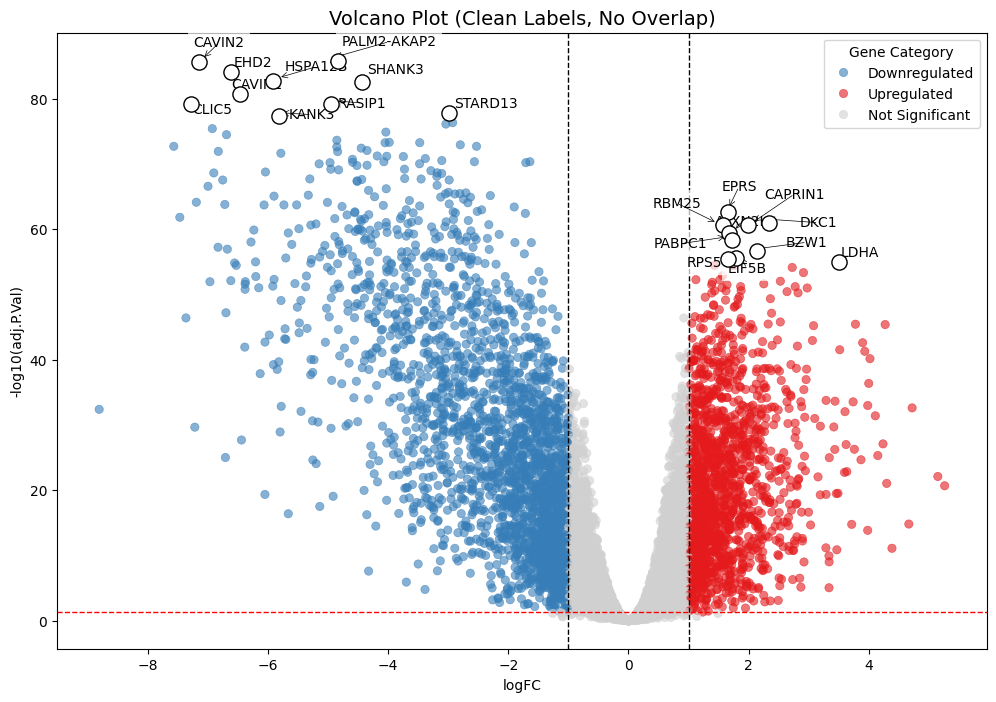

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# -------------------------
# log p-value


# -------------------------
# classification
# -------------------------
results['group'] = 'Not Significant'

results.loc[
    (results['logFC'] > 1) & (results['adj.P.Val'] < 0.05),
    'group'
] = 'Upregulated'

results.loc[
    (results['logFC'] < -1) & (results['adj.P.Val'] < 0.05),
    'group'
] = 'Downregulated'

# -------------------------
# TOP GENES (reduce to avoid clutter)
# -------------------------
top_up = results[(results['logFC'] > 1)].nsmallest(10, 'adj.P.Val')
top_down = results[(results['logFC'] < -1)].nsmallest(10, 'adj.P.Val')
top_genes = pd.concat([top_up, top_down]).copy()

# -------------------------
# jitter labels slightly (IMPORTANT FIX)
# -------------------------
top_genes['logFC_jit'] = top_genes['logFC'] + np.random.uniform(-0.1, 0.1, len(top_genes))
top_genes['logP_jit'] = top_genes['minus_log10_pvalue'] + np.random.uniform(0.2, 0.6, len(top_genes))

# -------------------------
# plot
# -------------------------
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=results,
    x='logFC',
    y='minus_log10_pvalue',
    hue='group',
    palette={
        'Not Significant': '#d0d0d0',
        'Upregulated': '#e41a1c',
        'Downregulated': '#377eb8'
    },
    alpha=0.6,
    edgecolor=None
)

# highlight top genes
plt.scatter(
    top_genes['logFC'],
    top_genes['minus_log10_pvalue'],
    c='white',
    s=120,
    edgecolor='black',
    zorder=5
)

# -------------------------
# labels (with jitter + repel)
# -------------------------
texts = []
for _, row in top_genes.iterrows():
    texts.append(
        plt.text(
            row['logFC_jit'],
            row['logP_jit'],
            row['GeneSymbol'],
            fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
        )
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='black', lw=0.5),
    expand_points=(2, 2),
    expand_text=(2, 2),
    force_text=(0.5, 0.5),
    force_points=(0.5, 0.5)
)

# -------------------------
# threshold lines
# -------------------------
plt.axvline(1, linestyle='--', color='black', linewidth=1)
plt.axvline(-1, linestyle='--', color='black', linewidth=1)
plt.axhline(-np.log10(0.05), linestyle='--', color='red', linewidth=1)

plt.title("Volcano Plot (Clean Labels, No Overlap)", fontsize=14)
plt.xlabel("logFC")
plt.ylabel("-log10(adj.P.Val)")

plt.legend(title="Gene Category")
plt.show()

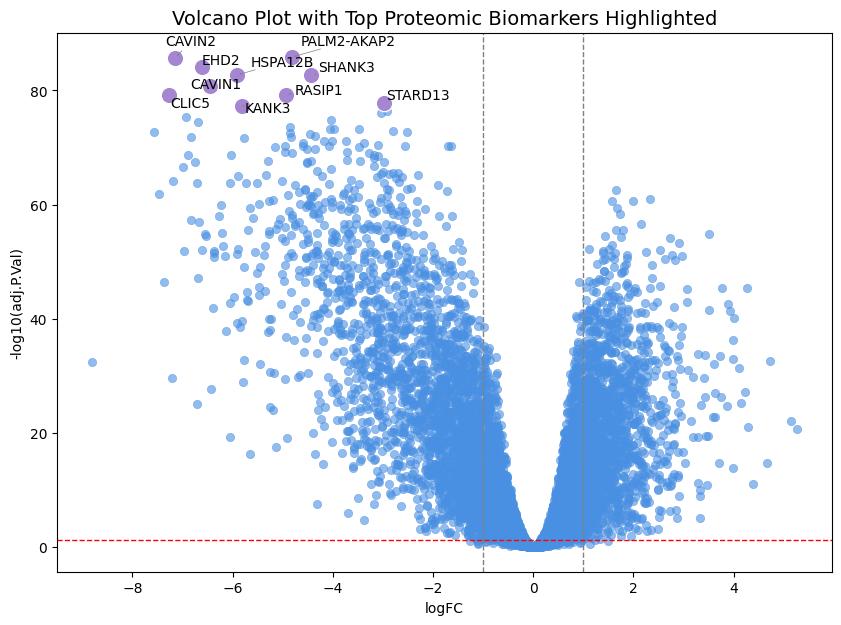

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text



# top genes
top_genes = results.nsmallest(10, 'adj.P.Val')

plt.figure(figsize=(10,7))

# base plot (blue theme)
sns.scatterplot(
    data=results,
    x='logFC',
    y='minus_log10_pvalue',
    color='#4A90E2',   # soft blue
    alpha=0.6,
    edgecolor=None
)

# highlight top genes (darker blue + bigger points)
sns.scatterplot(
    data=top_genes,
    x='logFC',
    y='minus_log10_pvalue',
    color='#a486d1',   # deep blue
    s=140
)

# collect text objects for smart positioning
texts = []
for _, row in top_genes.iterrows():
    texts.append(
        plt.text(
            row['logFC'],
            row['minus_log10_pvalue'],
            row['GeneSymbol'],
            fontsize=10,
            color='black'
        )
    )

# avoid overlapping labels
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.5)
)

# threshold lines
plt.axvline(1, linestyle='--', color='gray', linewidth=1)
plt.axvline(-1, linestyle='--', color='gray', linewidth=1)
plt.axhline(-np.log10(0.05), linestyle='--', color='red', linewidth=1)

plt.title("Volcano Plot with Top Proteomic Biomarkers Highlighted", fontsize=14)
plt.xlabel("logFC")
plt.ylabel("-log10(adj.P.Val)")

plt.show()

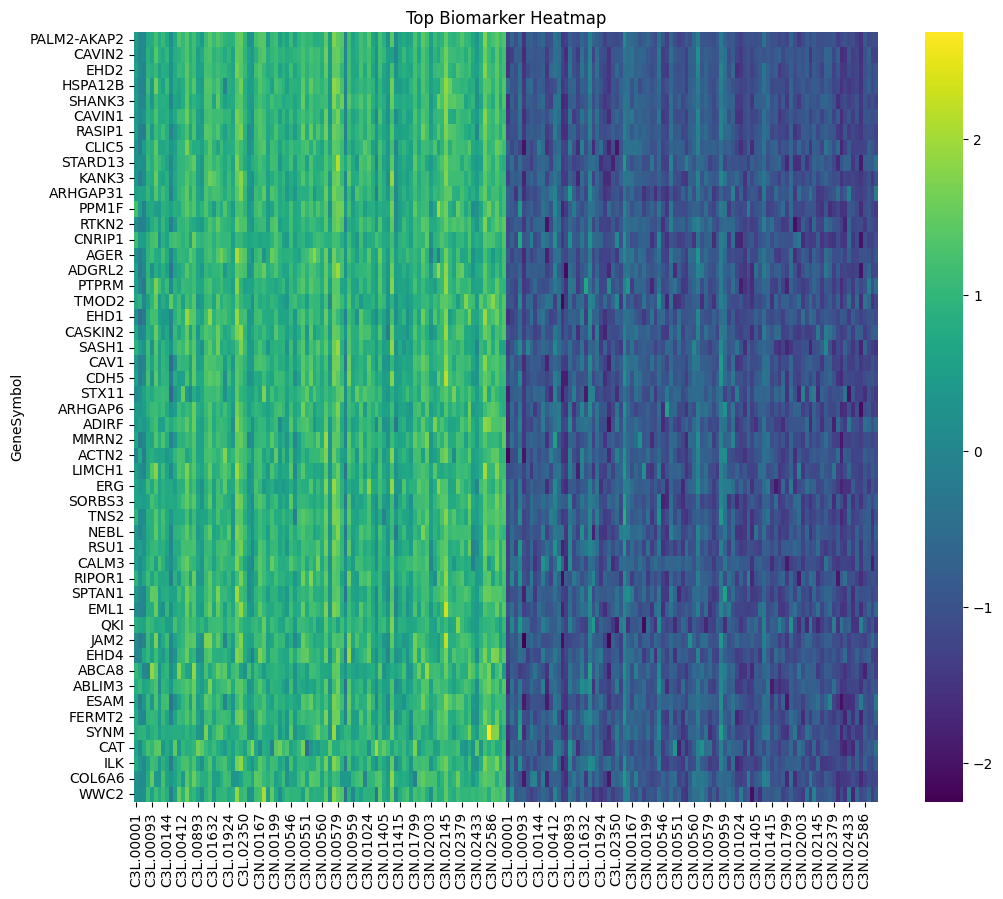

In [78]:
top_genes = biomarkers.head(50)['GeneSymbol']

heatmap_data = expr_log.loc[top_genes]

# z-score scaling
heatmap_scaled = heatmap_data.sub(
    heatmap_data.mean(axis=1),
    axis=0
).div(
    heatmap_data.std(axis=1),
    axis=0
)

plt.figure(figsize=(12,10))

sns.heatmap(
    heatmap_scaled,
    cmap='viridis'
)

plt.title("Top Biomarker Heatmap")

plt.show()

In [79]:
groups = ['Normal'] * n_normal + ['Tumor'] * n_tumor

print(groups[:5])
print(groups[-5:])

['Normal', 'Normal', 'Normal', 'Normal', 'Normal']
['Tumor', 'Tumor', 'Tumor', 'Tumor', 'Tumor']


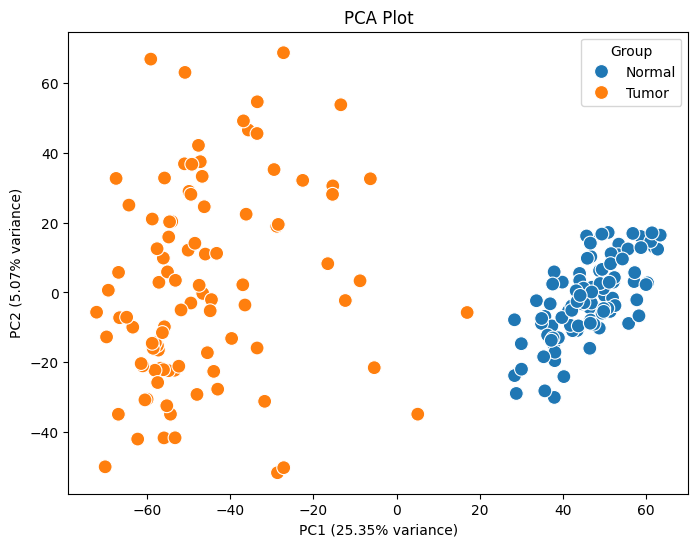

In [80]:
pca_input = expr_log.T

# handle inf/nan safely
pca_input = pca_input.replace([np.inf, -np.inf], np.nan)

# impute (safer than dropping samples)
pca_input = pca_input.fillna(pca_input.mean())

# standardize
scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_input)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(pca_scaled)

# use index alignment instead of slicing groups
pca_df = pd.DataFrame({
    'PC1': pca_result[:,0],
    'PC2': pca_result[:,1],
    'Group': groups  # must match sample order exactly
})

# plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Group',
    s=100
)

plt.title("PCA Plot")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)")
plt.show()

Top biomarker: PALM2-AKAP2
Normal mean: 2.4898197916666667
Tumor mean: -2.3355760416666667
AUC (original): 0.0003255208333333333
AUC (flipped): 0.9996744791666666
Using flipped expression for correct direction


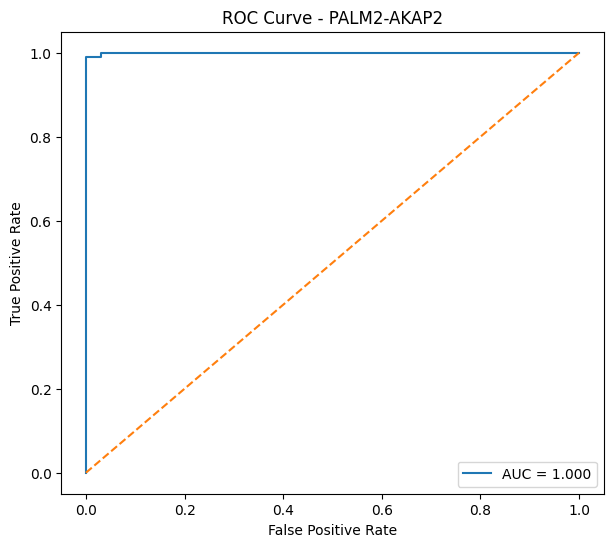

In [81]:
top_gene = biomarkers.iloc[0]['GeneSymbol']
print("Top biomarker:", top_gene)

# -------------------------
# 2. Extract expression safely
# -------------------------
gene_values = expr_log.loc[top_gene].replace([np.inf, -np.inf], np.nan)

# -------------------------
# 3. Build aligned dataframe (SAFE ALIGNMENT)
# -------------------------
labels = np.array([0]*n_normal + [1]*n_tumor)

df = pd.DataFrame({
    "expr": gene_values.values,
    "label": labels
})

df = df.dropna()

# -------------------------
# 4. Check group means (IMPORTANT DIAGNOSTIC)
# -------------------------
normal_mean = df[df["label"] == 0]["expr"].mean()
tumor_mean = df[df["label"] == 1]["expr"].mean()

print("Normal mean:", normal_mean)
print("Tumor mean:", tumor_mean)

# -------------------------
# 5. ROC (both directions to avoid AUC=0 issue)
# -------------------------
fpr, tpr, _ = roc_curve(df["label"], df["expr"])
auc1 = auc(fpr, tpr)

fpr2, tpr2, _ = roc_curve(df["label"], -df["expr"])
auc2 = auc(fpr2, tpr2)

print("AUC (original):", auc1)
print("AUC (flipped):", auc2)

# choose correct direction automatically
if auc2 > auc1:
    fpr, tpr, roc_auc = fpr2, tpr2, auc2
    print("Using flipped expression for correct direction")
else:
    roc_auc = auc1
    print("Using original expression")

# -------------------------
# 6. Plot ROC
# -------------------------
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {top_gene}")
plt.legend()

plt.show()

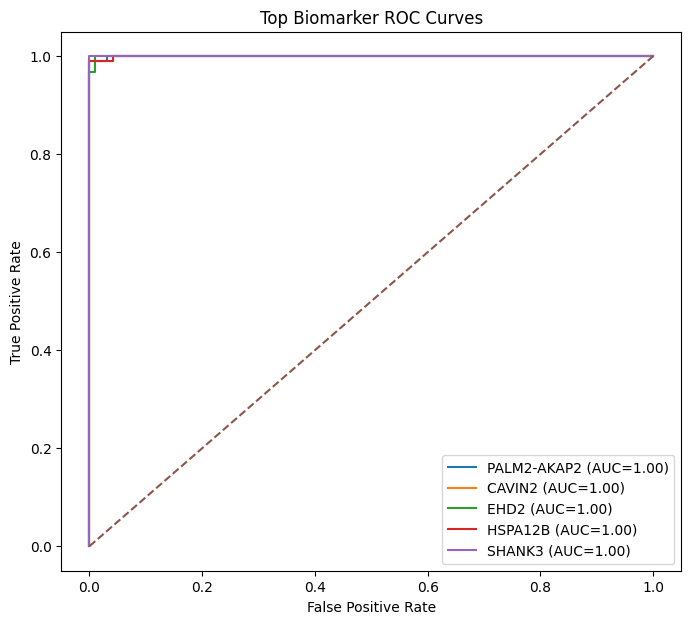

In [82]:
top5 = biomarkers.head(5)['GeneSymbol']

plt.figure(figsize=(8,7))
y_true = np.array([0]*n_normal + [1]*n_tumor)
y_true = np.array(y_true)

for gene in top5:

    values = expr_log.loc[gene].replace([np.inf, -np.inf], np.nan)

    # SAFE ALIGNMENT (NO MASK BUGS)
    df = pd.DataFrame({
        "expr": values.values,
        "label": y_true
    }).dropna()

    # ROC
    fpr, tpr, _ = roc_curve(df["label"], df["expr"])
    roc_auc = auc(fpr, tpr)

    # optional: auto-correct direction
    fpr2, tpr2, _ = roc_curve(df["label"], -df["expr"])
    auc2 = auc(fpr2, tpr2)

    if auc2 > roc_auc:
        fpr, tpr, roc_auc = fpr2, tpr2, auc2

    plt.plot(fpr, tpr, label=f'{gene} (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Top Biomarker ROC Curves")
plt.legend()
plt.show()

In [83]:
gene_list = biomarkers['GeneSymbol'].tolist()

print("Number of significant biomarkers:", len(gene_list))

gene_list[:20]

Number of significant biomarkers: 3770


['PALM2-AKAP2',
 'CAVIN2',
 'EHD2',
 'HSPA12B',
 'SHANK3',
 'CAVIN1',
 'RASIP1',
 'CLIC5',
 'STARD13',
 'KANK3',
 'ARHGAP31',
 'PPM1F',
 'RTKN2',
 'CNRIP1',
 'AGER',
 'ADGRL2',
 'PTPRM',
 'TMOD2',
 'EHD1',
 'CASKIN2']

In [84]:
go_results = gp.enrichr(
    gene_list=gene_list,
    gene_sets='GO_Biological_Process_2023',
    organism='human',
    outdir=None
)

go_df = go_results.results

go_df.head(10)


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Translation (GO:0006412),107/234,3.798529e-21,1.869256e-17,0,0,3.703820,174.152429,RPL5;RPL30;RPL32;APEH;RPL10A;RPL9;RPS15;EEF1B2...
1,GO_Biological_Process_2023,Ribosomal Small Subunit Biogenesis (GO:0042274),55/84,8.486655e-21,2.088141e-17,0,0,8.270803,382.241728,MRPS11;MRPS12;FCF1;NAT10;PWP2;WDR46;WDR43;RRP9...
2,GO_Biological_Process_2023,Ribonucleoprotein Complex Biogenesis (GO:0022613),64/118,7.839896e-18,1.286004e-14,0,0,5.173113,203.754973,RPL5;MRPS12;FCF1;NAT10;NOC2L;PWP2;WDR46;WDR43;...
3,GO_Biological_Process_2023,Ribosome Biogenesis (GO:0042254),75/155,6.222404e-17,7.655113e-14,0,0,4.097598,152.905111,RPL5;POP4;MRPS12;FCF1;NAT10;NOC2L;PWP2;WDR46;W...
4,GO_Biological_Process_2023,Mitochondrial Translation (GO:0032543),55/98,2.096473e-16,2.063349e-13,0,0,5.573163,201.197360,MRPS17;GFM1;MRPS15;MRPS11;MRPS12;MRPL39;MRPL34...
5,GO_Biological_Process_2023,Mitochondrial Gene Expression (GO:0140053),55/103,3.910673e-15,3.207404e-12,0,0,4.991083,165.579527,MRPS17;MRPS15;MRPS11;MRPS12;MRPL39;MRPL34;MRPL...
6,GO_Biological_Process_2023,Macromolecule Biosynthetic Process (GO:0009059),79/183,2.802339e-14,1.970045e-11,0,0,3.318764,103.564474,MRPS17;RPL5;RPL30;MRPS15;RPL32;MRPS11;MRPS12;R...
7,GO_Biological_Process_2023,Peptide Biosynthetic Process (GO:0043043),69/158,6.038771e-13,3.714599e-10,0,0,3.381197,95.131341,MRPS17;RPL5;RPL30;MRPS15;RPL32;MRPS11;MRPS12;R...
8,GO_Biological_Process_2023,rRNA Processing (GO:0006364),51/101,6.956474e-13,3.803646e-10,0,0,4.437645,124.227125,RPL5;POP4;NAT10;RRP9;RPS15;FBL;SART1;RPS17;RPS...
9,GO_Biological_Process_2023,Regulation Of Cell Migration (GO:0030334),143/434,1.110937e-12,5.466921e-10,0,0,2.159517,59.442462,SEMA5A;RIPOR1;CSF1;PLXND1;ZMYND8;TNC;ADARB1;FG...


In [85]:
print(go_df.head(10))

                     Gene_set  \
0  GO_Biological_Process_2023   
1  GO_Biological_Process_2023   
2  GO_Biological_Process_2023   
3  GO_Biological_Process_2023   
4  GO_Biological_Process_2023   
5  GO_Biological_Process_2023   
6  GO_Biological_Process_2023   
7  GO_Biological_Process_2023   
8  GO_Biological_Process_2023   
9  GO_Biological_Process_2023   

                                                Term  Overlap       P-value  \
0                           Translation (GO:0006412)  107/234  3.798529e-21   
1    Ribosomal Small Subunit Biogenesis (GO:0042274)    55/84  8.486655e-21   
2  Ribonucleoprotein Complex Biogenesis (GO:0022613)   64/118  7.839896e-18   
3                   Ribosome Biogenesis (GO:0042254)   75/155  6.222404e-17   
4             Mitochondrial Translation (GO:0032543)    55/98  2.096473e-16   
5         Mitochondrial Gene Expression (GO:0140053)   55/103  3.910673e-15   
6    Macromolecule Biosynthetic Process (GO:0009059)   79/183  2.802339e-14   
7   

In [86]:
clean_go = go_df[['Term', 'P-value', 'Adjusted P-value', 'Combined Score', 'Genes']] \
    .sort_values('Adjusted P-value') \
    .head(10).copy()

# keep only first 5 genes
clean_go['Genes'] = clean_go['Genes'].apply(lambda x: ';'.join(x.split(';')[:5]))

clean_go.to_csv("top10_GO_terms.csv", index=False)
clean_go

,Term,P-value,Adjusted P-value,Combined Score,Genes
0,Translation (GO:0006412),3.798529e-21,1.869256e-17,174.152429,RPL5;RPL30;RPL32;APEH;RPL10A
1,Ribosomal Small Subunit Biogenesis (GO:0042274),8.486655e-21,2.088141e-17,382.241728,MRPS11;MRPS12;FCF1;NAT10;PWP2
2,Ribonucleoprotein Complex Biogenesis (GO:0022613),7.839896e-18,1.286004e-14,203.754973,RPL5;MRPS12;FCF1;NAT10;NOC2L
3,Ribosome Biogenesis (GO:0042254),6.222404e-17,7.655113e-14,152.905111,RPL5;POP4;MRPS12;FCF1;NAT10
4,Mitochondrial Translation (GO:0032543),2.096473e-16,2.063349e-13,201.197360,MRPS17;GFM1;MRPS15;MRPS11;MRPS12
5,Mitochondrial Gene Expression (GO:0140053),3.910673e-15,3.207404e-12,165.579527,MRPS17;MRPS15;MRPS11;MRPS12;MRPL39
6,Macromolecule Biosynthetic Process (GO:0009059),2.802339e-14,1.970045e-11,103.564474,MRPS17;RPL5;RPL30;MRPS15;RPL32
7,Peptide Biosynthetic Process (GO:0043043),6.038771e-13,3.714599e-10,95.131341,MRPS17;RPL5;RPL30;MRPS15;RPL32
8,rRNA Processing (GO:0006364),6.956474e-13,3.803646e-10,124.227125,RPL5;POP4;NAT10;RRP9;RPS15
9,Regulation Of Cell Migration (GO:0030334),1.110937e-12,5.466921e-10,59.442462,SEMA5A;RIPOR1;CSF1;PLXND1;ZMYND8


In [87]:
kegg_results = gp.enrichr(
    gene_list=gene_list,
    gene_sets='KEGG_2021_Human',
    organism='human',
    outdir=None
)

kegg_df = kegg_results.results

kegg_df.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Complement and coagulation cascades,70/85,9.568655e-37,3.042832e-34,0,0,20.451351,1696.176914,SERPINA1;PROS1;F13A1;C4BPA;PLAT;C4BPB;C8B;C8A;...
1,KEGG_2021_Human,ECM-receptor interaction,52/88,6.718705e-17,1.068274e-14,0,0,6.291375,234.284846,ITGB1;LAMC3;ITGB3;ITGA2B;TNC;LAMC2;LAMC1;COMP;...
2,KEGG_2021_Human,Focal adhesion,88/201,3.397068e-16,3.600892e-14,0,0,3.408825,121.417043,ITGB1;MYLK2;FLT1;LAMC3;ITGB3;ITGA2B;TNC;ILK;LA...
3,KEGG_2021_Human,Coronavirus disease,93/232,3.753780e-14,2.984255e-12,0,0,2.927909,90.511700,RPL5;RPL30;RPL32;RPLP0;F13A1;ADAR;C8B;RPL10A;R...
4,KEGG_2021_Human,Platelet activation,60/124,7.806358e-14,4.964843e-12,0,0,4.085074,123.292655,ITGB1;MYLK2;GUCY1B1;ITGB3;ITGA2B;ACTB;MYLK3;AC...
5,KEGG_2021_Human,Ribosome,70/158,1.742544e-13,9.235485e-12,0,0,3.470332,101.952306,MRPS17;RPL5;RPL30;MRPS15;RPL32;MRPS11;MRPS12;R...
6,KEGG_2021_Human,Protein processing in endoplasmic reticulum,69/171,5.035931e-11,2.287752e-09,0,0,2.947884,69.899740,ERO1A;ERO1B;TRAM1;HSP90AB1;UBXN2A;PRKCSH;HERPU...
7,KEGG_2021_Human,Phagosome,61/152,8.400126e-10,3.339050e-08,0,0,2.916811,60.954354,ITGB1;SCARB1;NCF1;TFRC;NCF2;ITGB3;ACTB;FCAR;AC...
8,KEGG_2021_Human,Protein export,18/23,1.104964e-09,3.904204e-08,0,0,15.567697,321.059680,SRP19;HSPA5;SRP54;SRP68;SRP14;OXA1L;SEC61A1;SP...
9,KEGG_2021_Human,Cholesterol metabolism,28/50,5.249458e-09,1.669328e-07,0,0,5.512657,105.099589,SCARB1;CETP;LRP1;PCSK9;LCAT;LPL;LIPA;APOH;CD36...


In [88]:
# keep only important KEGG columns
clean_kegg = kegg_df[['Term', 'P-value', 'Adjusted P-value',
                      'Combined Score', 'Genes']] \
    .sort_values('Adjusted P-value') \
    .head(10) \
    .copy()

# keep only first 5 genes
clean_kegg['Genes'] = clean_kegg['Genes'].apply(
    lambda x: ';'.join(x.split(';')[:5])
)
clean_kegg.to_csv("top10_KEGG_terms.csv", index=False)

clean_kegg

,Term,P-value,Adjusted P-value,Combined Score,Genes
0,Complement and coagulation cascades,9.568655e-37,3.042832e-34,1696.176914,SERPINA1;PROS1;F13A1;C4BPA;PLAT
1,ECM-receptor interaction,6.718705e-17,1.068274e-14,234.284846,ITGB1;LAMC3;ITGB3;ITGA2B;TNC
2,Focal adhesion,3.397068e-16,3.600892e-14,121.417043,ITGB1;MYLK2;FLT1;LAMC3;ITGB3
3,Coronavirus disease,3.753780e-14,2.984255e-12,90.511700,RPL5;RPL30;RPL32;RPLP0;F13A1
4,Platelet activation,7.806358e-14,4.964843e-12,123.292655,ITGB1;MYLK2;GUCY1B1;ITGB3;ITGA2B
5,Ribosome,1.742544e-13,9.235485e-12,101.952306,MRPS17;RPL5;RPL30;MRPS15;RPL32
6,Protein processing in endoplasmic reticulum,5.035931e-11,2.287752e-09,69.899740,ERO1A;ERO1B;TRAM1;HSP90AB1;UBXN2A
7,Phagosome,8.400126e-10,3.339050e-08,60.954354,ITGB1;SCARB1;NCF1;TFRC;NCF2
8,Protein export,1.104964e-09,3.904204e-08,321.059680,SRP19;HSPA5;SRP54;SRP68;SRP14
9,Cholesterol metabolism,5.249458e-09,1.669328e-07,105.099589,SCARB1;CETP;LRP1;PCSK9;LCAT


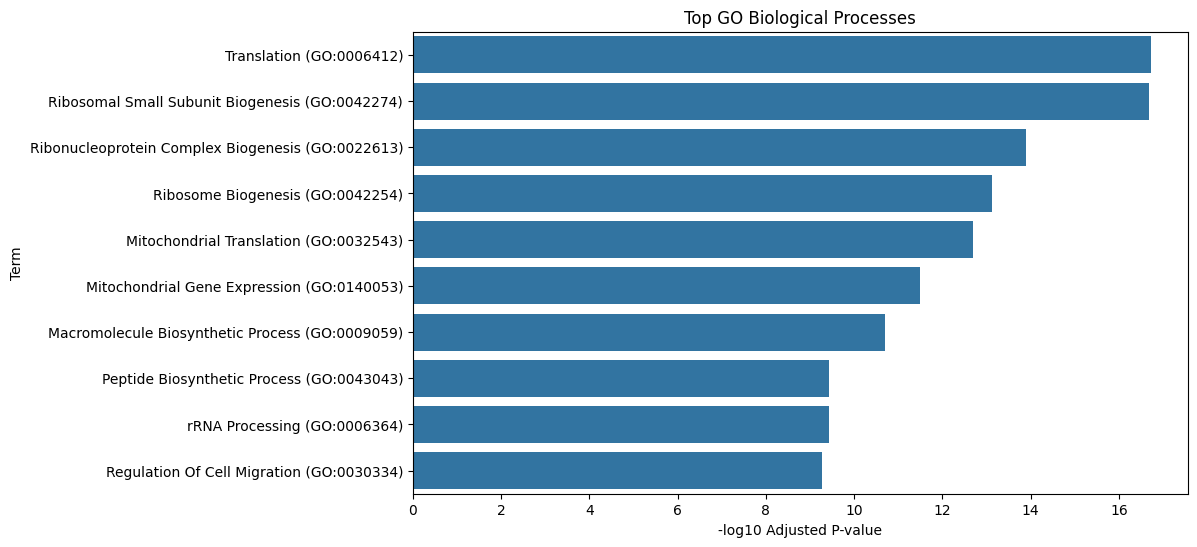

In [89]:
top_go = go_df.sort_values('Adjusted P-value').head(10).copy()

# convert to -log10 scale
top_go['log_adj_p'] = -np.log10(top_go['Adjusted P-value'])

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_go,
    x='log_adj_p',
    y='Term'
)

plt.xlabel('-log10 Adjusted P-value')
plt.title("Top GO Biological Processes")

plt.show()

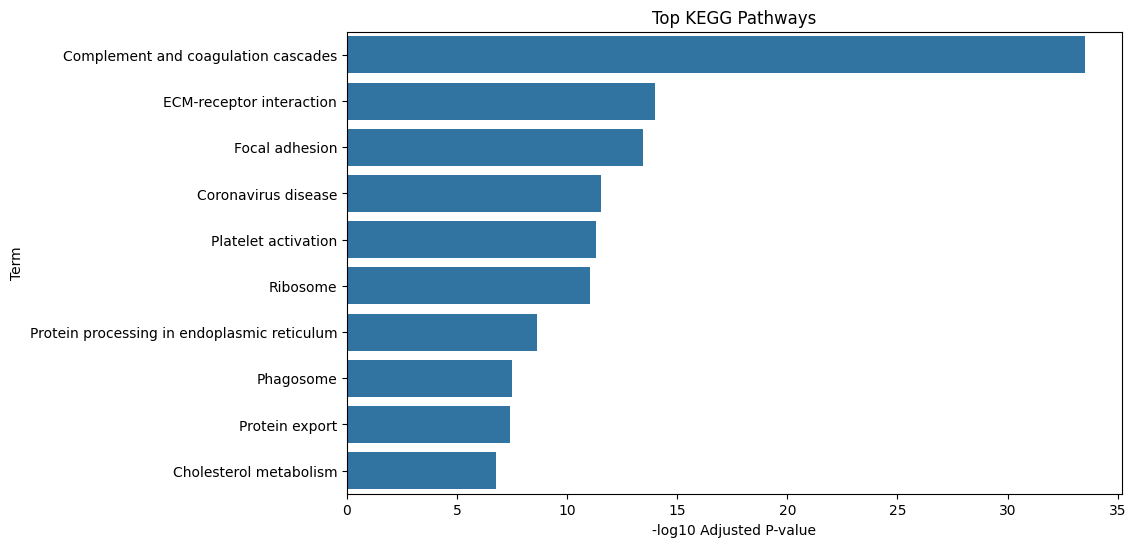

In [90]:
top_kegg = kegg_df.sort_values('Adjusted P-value').head(10).copy()

# convert p-values
top_kegg['log_adj_p'] = -np.log10(top_kegg['Adjusted P-value'])

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_kegg,
    x='log_adj_p',
    y='Term'
)

plt.xlabel('-log10 Adjusted P-value')
plt.title("Top KEGG Pathways")

plt.show()


In [63]:
gene_list = biomarkers['GeneSymbol'].tolist()
y_true = np.array(y_true)

results = []

# -----------------------------
# LOOP OVER ALL GENES
# -----------------------------
for gene in gene_list:

    values = expr_log.loc[gene].replace([np.inf, -np.inf], np.nan)

    # align safely
    df = pd.DataFrame({
        "expr": values.values,
        "label": y_true
    }).dropna()

    # skip genes with insufficient data
    if df["label"].nunique() < 2:
        continue

    try:
        # ROC original
        fpr, tpr, _ = roc_curve(df["label"], df["expr"])
        auc1 = auc(fpr, tpr)

        # ROC flipped (handles downregulated genes)
        fpr2, tpr2, _ = roc_curve(df["label"], -df["expr"])
        auc2 = auc(fpr2, tpr2)

        best_auc = max(auc1, auc2)

        results.append({
            "Gene": gene,
            "AUC": best_auc
        })

    except:
        continue

# -----------------------------
# CREATE RESULT TABLE
# -----------------------------
results_df = pd.DataFrame(results)

# remove weak biomarkers
final_biomarkers = results_df[results_df["AUC"] >= 0.75]

# sort by performance
final_biomarkers = final_biomarkers.sort_values(by="AUC", ascending=False)

# reset index
final_biomarkers = final_biomarkers.reset_index(drop=True)

# -----------------------------
# OUTPUT
# -----------------------------
print("Total genes tested:", len(results_df))
print("Final biomarkers (AUC ≥ 0.75):", len(final_biomarkers))

final_biomarkers.head(20)

Total genes tested: 3770
Final biomarkers (AUC ≥ 0.75): 3371


,Gene,AUC
0,SHANK3,1.000000
1,CLIC5,0.999783
2,ERG,0.999783
3,CAVIN1,0.999783
4,EHD2,0.999674
5,PALM2-AKAP2,0.999674
6,HSPA12B,0.999566
7,RTKN2,0.999566
8,EHD4,0.999566
9,CAVIN2,0.999566


In [64]:
final_biomarkers.to_csv("final_biomarker_panel.csv", index=False)

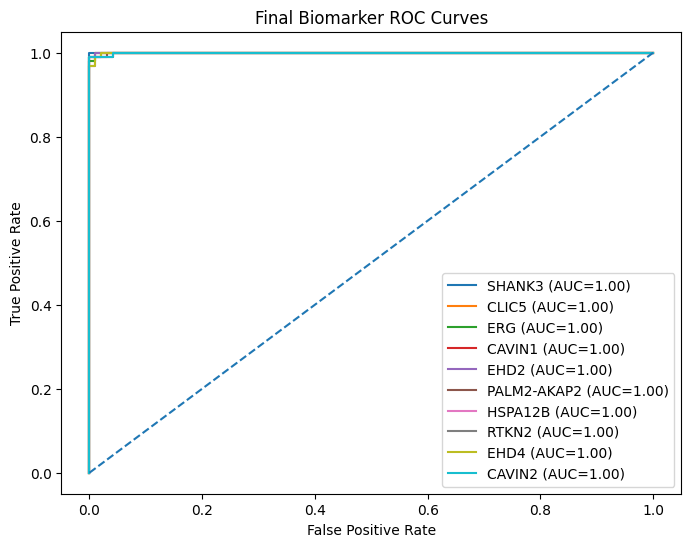

In [65]:
import matplotlib.pyplot as plt

top5 = final_biomarkers.head(10)["Gene"]

plt.figure(figsize=(8,6))

for gene in top5:

    values = expr_log.loc[gene].replace([np.inf, -np.inf], np.nan)

    df = pd.DataFrame({
        "expr": values.values,
        "label": y_true
    }).dropna()

    fpr, tpr, _ = roc_curve(df["label"], df["expr"])
    auc_val = auc(fpr, tpr)

    fpr2, tpr2, _ = roc_curve(df["label"], -df["expr"])
    auc2 = auc(fpr2, tpr2)

    if auc2 > auc_val:
        fpr, tpr, auc_val = fpr2, tpr2, auc2

    plt.plot(fpr, tpr, label=f"{gene} (AUC={auc_val:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Biomarker ROC Curves")
plt.legend()
plt.show()

In [66]:
print(biomarkers.columns)

Index(['GeneSymbol', 'logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B'], dtype='object')


In [67]:
import pandas as pd
from statsmodels.stats.multitest import multipletests

# assume you already have:
# final_biomarkers = Gene + AUC table
# biomarkers dataframe contains p-value info

# -----------------------------
# 1. Merge AUC + statistics
# -----------------------------
df = final_biomarkers.copy()

# adjust these column names if needed
# common in DE results: "pvalue", "p-value", "P.Value"
df = df.merge(
    biomarkers[['GeneSymbol', 'P.Value']],
    left_on='Gene',
    right_on='GeneSymbol',
    how='left'
)

# drop extra column
df = df.drop(columns=['GeneSymbol'])

# -----------------------------
# 2. Compute adjusted p-value (FDR)
# -----------------------------
df['adj_pvalue'] = multipletests(df['P.Value'], method='fdr_bh')[1]

# -----------------------------
# 3. Clean final table
# -----------------------------
df = df.sort_values(by='AUC', ascending=False)

df = df[['Gene', 'AUC', 'P.Value', 'adj_pvalue']]

# -----------------------------
# 4. Show top results
# -----------------------------
df_top10 = df.head(10)
print(df_top10)
df_top10.to_csv("final_biomarker_top10.csv", index=False)

           Gene       AUC       P.Value    adj_pvalue
0        SHANK3  1.000000  1.263917e-86  8.521328e-84
1         CLIC5  0.999783  4.313494e-83  1.967956e-80
2           ERG  0.999783  2.136888e-74  2.401150e-72
3        CAVIN1  0.999783  1.233299e-84  6.929083e-82
4          EHD2  0.999674  2.892871e-88  3.250623e-85
5   PALM2-AKAP2  0.999674  1.619873e-90  5.460593e-87
8          EHD4  0.999566  4.155928e-73  3.416984e-71
9        CAVIN2  0.999566  4.343977e-90  7.321773e-87
7         RTKN2  0.999566  5.426782e-79  1.407206e-76
10          QKI  0.999566  2.721205e-73  2.293295e-71
